In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

In [9]:
model_df = pd.read_csv("data/processed/asteroid_diameter_data.csv")

### Ordinary Least Squares

In [10]:
ols_df = model_df[["H","diameter"]].dropna()

In [11]:
ols_df.head()

,H,diameter
0,3.34,939.400
1,4.12,513.000
2,5.19,246.596
3,3.25,522.770
4,6.95,106.699


In [12]:
X = ols_df["H"]
y = ols_df["diameter"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               diameter   R-squared:                       0.319
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                 6.472e+04
Date:                Sat, 27 Jun 2026   Prob (F-statistic):               0.00
Time:                        10:46:33   Log-Likelihood:            -4.7808e+05
No. Observations:              138084   AIC:                         9.562e+05
Df Residuals:                  138082   BIC:                         9.562e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         61.9282      0.223    277.925      0.0

In [13]:
ols_df["diameter_pred"] = model.predict(X)
ols_df.head()

,H,diameter,diameter_pred
0,3.34,939.400,49.632862
1,4.12,513.000,46.761490
2,5.19,246.596,42.822557
3,3.25,522.770,49.964174
4,6.95,106.699,36.343564


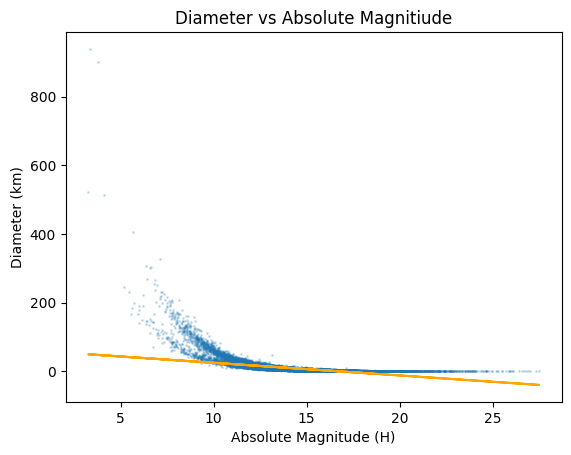

In [14]:
plt.scatter(ols_df["H"], ols_df["diameter"], s=1, alpha=0.2)
plt.plot(ols_df["H"], ols_df["diameter_pred"], color="orange")
plt.title("Diameter vs Absolute Magnitiude")
plt.xlabel("Absolute Magnitude (H)")
plt.ylabel("Diameter (km)")
plt.show()

#### Variable Tranformation

In [15]:
ols_df = model_df[["H", "diameter"]].dropna().copy()
ols_df["log_diameter"] = np.log10(ols_df["diameter"])
X = sm.add_constant(ols_df["H"]) # Add constant for intercept
y = ols_df["log_diameter"]
log_model = sm.OLS(y, X).fit()
print(log_model.summary())


                            OLS Regression Results                            
Dep. Variable:           log_diameter   R-squared:                       0.702
Model:                            OLS   Adj. R-squared:                  0.702
Method:                 Least Squares   F-statistic:                 3.253e+05
Date:                Sat, 27 Jun 2026   Prob (F-statistic):               0.00
Time:                        10:48:19   Log-Likelihood:                 62097.
No. Observations:              138084   AIC:                        -1.242e+05
Df Residuals:                  138082   BIC:                        -1.242e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.1476      0.004    706.239      0.0

In [16]:
ols_df["diameter_pred_log"] = log_model.predict(X)
ols_df.head()

,H,diameter,log_diameter,diameter_pred_log
0,3.34,939.400,2.972851,2.596291
1,4.12,513.000,2.710117,2.467539
2,5.19,246.596,2.391986,2.290918
3,3.25,522.770,2.718311,2.611147
4,6.95,106.699,2.028160,2.000400


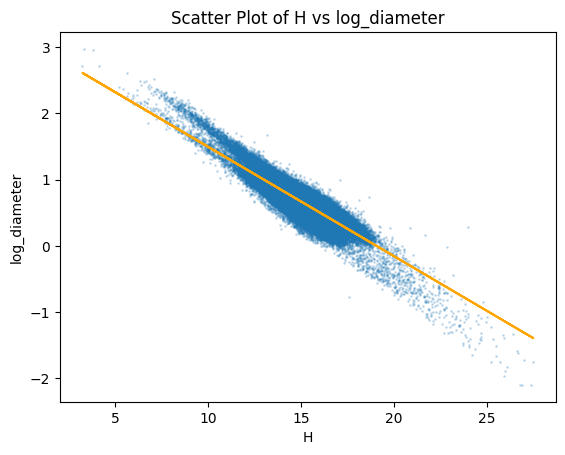

In [17]:
plt.scatter(ols_df["H"], ols_df["log_diameter"], s=1, alpha=0.2)
plt.plot(ols_df["H"], ols_df["diameter_pred_log"], color="orange")
plt.xlabel("H")
plt.ylabel("log_diameter")
plt.title("Scatter Plot of H vs log_diameter")
plt.show()

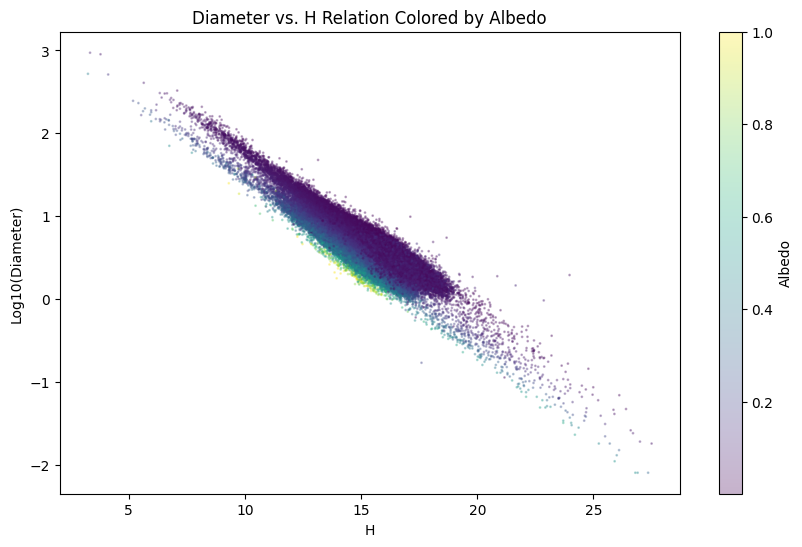

In [25]:
plt.figure(figsize=(10,6))
plt.scatter(
    model_df["H"],
    np.log10(model_df["diameter"]), # Model_df has no log_diameter column, so we calculate it on the fly
    c=model_df["albedo"],
    s=1,
    alpha=0.3
)

plt.colorbar(label="Albedo")

plt.xlabel("H")
plt.ylabel("Log10(Diameter)")
plt.title("Diameter vs. H Relation Colored by Albedo")

plt.show()

Text(0.5, 1.0, 'Histogram of Albedo')

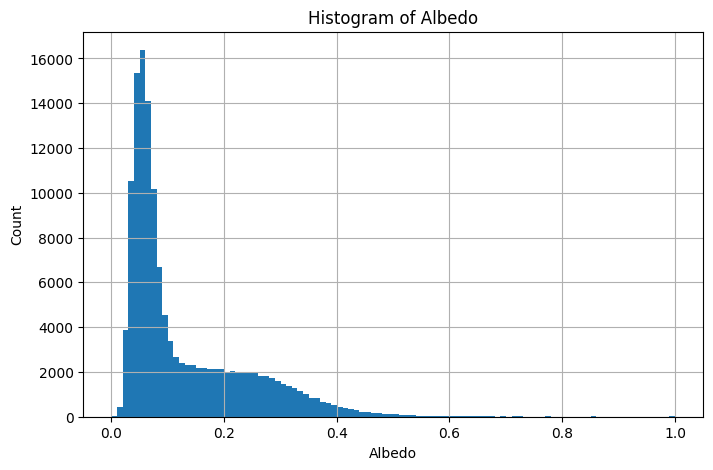

In [28]:
model_df["albedo"].hist(bins=100, figsize=(8,5))

plt.xlabel("Albedo")
plt.ylabel("Count")
plt.title("Histogram of Albedo")